<a href="https://colab.research.google.com/github/luciacubero20/Practicas_Redes_Neuronales_LuciaCubero/blob/main/Practica_03_Luc%C3%ADaCubero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="darkorange" size="10"><b>03. Regresión con MLP</b></font>

Lucía Cubero Alonso

Correo institucional: lucicube@ucm.es


## Ejercicio 1.

Con los datos de este ejemplo crea una red neuronal que sea capaz de generar un error de cero (es decir, la linea de MLP atraviesa todos los puntos).



In [ ]:
%reset -f

In [ ]:
# Importamos las librerias que vamos a necesitar

import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

In [ ]:
# Generamos unos datos de X e y usando numpy

X = np.array(
    [258.0, 270.0, 294.0, 320.0, 342.0, 368.0, 396.0, 446.0, 480.0, 586.0]
)[:, np.newaxis]

y = np.array(
    [236.4, 234.4, 252.8, 298.6, 314.2, 342.2, 360.8, 368.0, 391.2, 390.8]
)

In [ ]:
# Comprobamos que se han creado bien

print(X)
print(y)

[[258.]
 [270.]
 [294.]
 [320.]
 [342.]
 [368.]
 [396.]
 [446.]
 [480.]
 [586.]]
[236.4 234.4 252.8 298.6 314.2 342.2 360.8 368.  391.2 390.8]


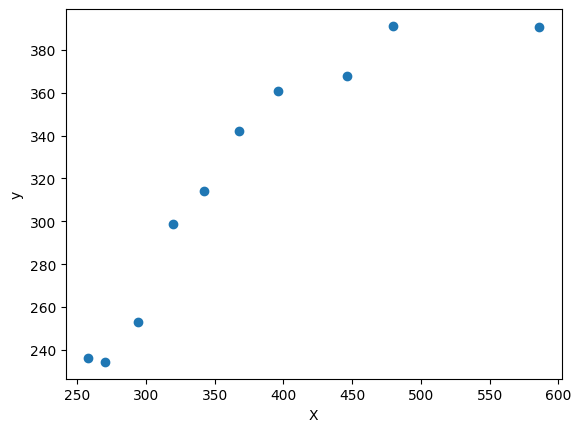

In [ ]:
# Ploteamos X e y

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [ ]:
# Vamos a utilizar la funcion LinearRegression del paquete sklearn para calcular la recta a esos puntos

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)

# create predictions for plotting
X_range = np.arange(250, 600, 10)[:, np.newaxis] # de nuevo creamos una matrix nx1 en vez de un vector
y_linear = lr.predict(X_range)

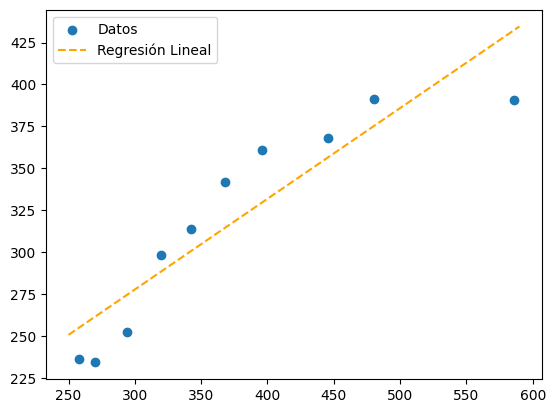

In [ ]:
# Dibujamos tanto los puntos como la recta

plt.scatter(X, y, label="Datos")
plt.plot(X_range, y_linear, label="Regresión Lineal", linestyle="--", color="orange")
plt.legend()
plt.show()

In [ ]:
# preparamos los datos

from torch.utils.data import TensorDataset, DataLoader

# Normalizamos X e y
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_norm = (X - x_mean) / x_std
y_norm = (y - y_mean) / y_std

# Pasamos las variables a tensores
tensor_X = torch.Tensor(X_norm) # transform to torch tensor
tensor_y = torch.Tensor(y_norm)

# Creamos el dataset y el dataloader
my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset) # create your dataloader

In [ ]:
# Definimos la red como una clase, es lo recomendado
# vamos a crear una red con:
#   - Una entrada con las dimensiones de X
#   - Una capa oculta de 1 neurona
#   - Una de salida con una unica neurona sin activación


class MLP(torch.nn.Module):
    def __init__(self, X_nvars):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # Hidden Layer 1
            torch.nn.Linear(X_nvars, 50), # Hacemos el sumatorio
            torch.nn.ReLU(),              # Aplicamos la función de activacion

            # output layer
            torch.nn.Linear(50, 1),
        )

    def forward(self, x):
        output = self.layers(x)
        return output

In [ ]:
# Fijamos la semilla a un valor para que los resultados sean identicos
torch.manual_seed(1)

# Ahora fijamos algunos hiper-parámetros

# Creamos el modelo MLP
model = MLP(X_nvars=1)

# Definimos la función loss
loss_fn = torch.nn.MSELoss()

# Elegimos el optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [ ]:
import torch.nn.functional as F

# Fijamos el número de épocas o iteraciones
num_epochs = 2500

# Una variables donde vamos a ir guardando los valores del loss para ploterarlos
loss_history = []

for epoch in range(num_epochs):
    model = model.train() # se fijan algunas cosas para hacer entrenamiento

    # En esta parte se define el batch
    # No te preocupes que aún no sabemos qué es
    # MUY IMPORTANTE, nunca uses el mismo nombre que tus datos o los sobreescribe
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        output = model(features)            # Hacemos el forward
        loss = loss_fn(output, targets.view(-1, 1))      # Calculamos el loss, targets matriz columna

        optimizer.zero_grad()        # Ponemos a cero el gradiente
        loss.backward()              # Calculamos los gradientes (la derivada del loss)
        optimizer.step()             # Cambiamos los pesos de la red

        # Cada cierto tiempo vamos a imprimir un poco de información
        # para saber qué está pasando
        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                # f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss.item():.2f}"
            )
        # añadimos el loss a loss_history
    loss_history.append(loss.item())

Epoch: 001/2500 | Batch 000/010 | Train Loss: 2.30
Epoch: 002/2500 | Batch 000/010 | Train Loss: 1.43
Epoch: 003/2500 | Batch 000/010 | Train Loss: 0.61
Epoch: 004/2500 | Batch 000/010 | Train Loss: 0.37
Epoch: 005/2500 | Batch 000/010 | Train Loss: 0.27
Epoch: 006/2500 | Batch 000/010 | Train Loss: 0.21
Epoch: 007/2500 | Batch 000/010 | Train Loss: 0.17
Epoch: 008/2500 | Batch 000/010 | Train Loss: 0.14
Epoch: 009/2500 | Batch 000/010 | Train Loss: 0.11
Epoch: 010/2500 | Batch 000/010 | Train Loss: 0.09
Epoch: 011/2500 | Batch 000/010 | Train Loss: 0.07
Epoch: 012/2500 | Batch 000/010 | Train Loss: 0.06
Epoch: 013/2500 | Batch 000/010 | Train Loss: 0.05
Epoch: 014/2500 | Batch 000/010 | Train Loss: 0.04
Epoch: 015/2500 | Batch 000/010 | Train Loss: 0.03
Epoch: 016/2500 | Batch 000/010 | Train Loss: 0.02
Epoch: 017/2500 | Batch 000/010 | Train Loss: 0.02
Epoch: 018/2500 | Batch 000/010 | Train Loss: 0.01
Epoch: 019/2500 | Batch 000/010 | Train Loss: 0.01
Epoch: 020/2500 | Batch 000/010

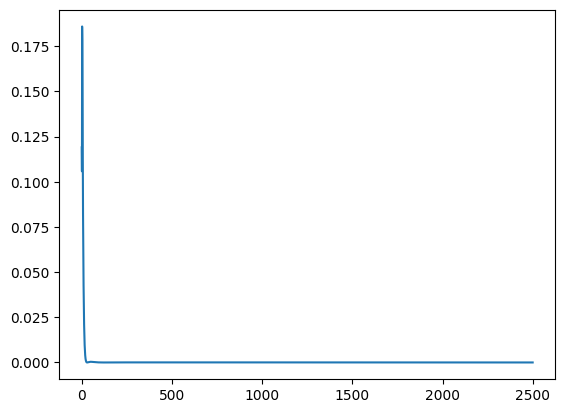

In [ ]:
# Vamos a hacer un plot del loss, a ver qué ha pasado

plt.plot(loss_history)

In [ ]:
# Vamos a evaluar el funcionamiento del modelo

model.eval() # se fijan parametros del modelo para evaluar

# predecimos los valores del rango X_range segun el MLP

# Se pasan a un tensor normalizado
X_range_norm = (X_range - x_mean) / x_std
X_range_norm = torch.tensor(X_range_norm, dtype=torch.float32)

# Se meten en el modelo
y_mlp_norm = model(X_range_norm)

# Ahora se desnormalizan para que estén en la misma escala
y_mlp_norm = y_mlp_norm.detach().numpy().astype(np.float64) # dejan de ser un tensor
y_mlp = y_mlp_norm * y_std + y_mean # desnormalizan

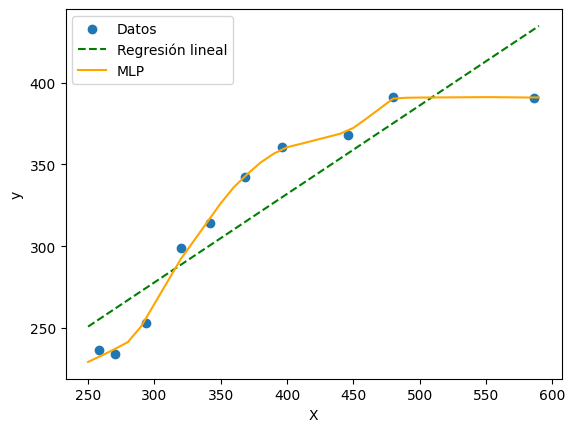

In [ ]:
# Vamos a hacer un plot con los resultados

# Los datos originales
plt.scatter(X, y, label="Datos")

# Los datos predichos por la regresion lineal
plt.plot(X_range, y_linear, label="Regresión lineal", linestyle="--", color='green')

# Los datos predichos por el MLP
plt.plot(X_range, y_mlp, label="MLP", color='orange')

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Ejercicio 2.

Usando el código siguiente, construye un MLP que se ajuste razonablemente a los puntos de ese seno. Puedes jugar con la creación de datos.


In [ ]:
%reset -f

In [ ]:
# Importamos las librerias que vamos a necesitar

import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

(100,)
(100,)


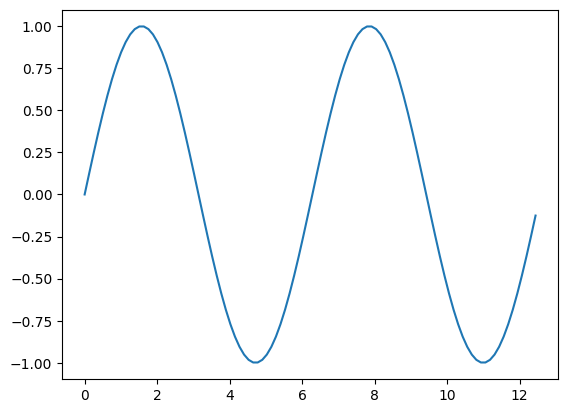

In [ ]:
# Creamos los datos, en este caso un seno

import numpy as np

cycles = 2  # numero de periodos
n = 100     # numero de datos en x

length = 2 * np.pi * cycles

X = np.arange(0, length, length / n)
y = np.sin(X)

plt.plot(X, y, '-')

print(X.shape)
print(y.shape)

In [ ]:
# preparamos los datos

from torch.utils.data import TensorDataset, DataLoader

# Normalizamos X e y
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_norm = (X - x_mean) / x_std
y_norm = (y - y_mean) / y_std

# Pasamos las variables a tensores
tensor_X = torch.Tensor(X_norm) # transform to torch tensor
tensor_y = torch.Tensor(y_norm)

# Creamos el dataset y el dataloader
my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset) # create your dataloader

In [ ]:
# Definimos la red como una clase, es lo recomendado
# vamos a crear una red con:
#   - Una entrada con las dimensiones de X
#   - Una capa oculta de 1 neurona
#   - Una de salida con una unica neurona sin activación


class MLP(torch.nn.Module):
    def __init__(self, X_nvars):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # Hidden Layer 1
            torch.nn.Linear(X_nvars, 30), # Hacemos el sumatorio
            torch.nn.ReLU(),              # Aplicamos la función de activacion

            # Hidden Layer 2
            torch.nn.Linear(30, 30), # Hacemos el sumatorio
            torch.nn.ReLU(),              # Aplicamos la función de activacion


            # output layer
            torch.nn.Linear(30, 1),
        )

    def forward(self, x):
        output = self.layers(x)
        return output

In [ ]:
# Fijamos la semilla a un valor para que los resultados sean identicos
torch.manual_seed(1)

# Ahora fijamos algunos hiper-parámetros

# Creamos el modelo MLP
model = MLP(X_nvars=1)

# Definimos la función loss
loss_fn = torch.nn.MSELoss()

# Elegimos el optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)


In [ ]:
import torch.nn.functional as F

# Fijamos el número de épocas o iteraciones
num_epochs = 800

# Una variables donde vamos a ir guardando los valores del loss para ploterarlos
loss_history = []

for epoch in range(num_epochs):
    model = model.train() # se fijan algunas cosas para hacer entrenamiento

    # En esta parte se define el batch
    # No te preocupes que aún no sabemos qué es
    # MUY IMPORTANTE, nunca uses el mismo nombre que tus datos o los sobreescribe
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        output = model(features)            # Hacemos el forward
        loss = loss_fn(output, targets)     # Calculamos el loss

        optimizer.zero_grad()        # Ponemos a cero el gradiente
        loss.backward()              # Calculamos los gradientes (la derivada del loss)
        optimizer.step()             # Cambiamos los pesos de la red

        # Cada cierto tiempo vamos a imprimir un poco de información
        # para saber qué está pasando
        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                # f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss.item():.2f}"
            )
        # añadimos el loss a loss_history
    loss_history.append(loss.item())

Epoch: 001/800 | Batch 000/100 | Train Loss: 0.01
Epoch: 002/800 | Batch 000/100 | Train Loss: 0.01
Epoch: 003/800 | Batch 000/100 | Train Loss: 0.02
Epoch: 004/800 | Batch 000/100 | Train Loss: 0.13
Epoch: 005/800 | Batch 000/100 | Train Loss: 0.27
Epoch: 006/800 | Batch 000/100 | Train Loss: 0.42
Epoch: 007/800 | Batch 000/100 | Train Loss: 0.54
Epoch: 008/800 | Batch 000/100 | Train Loss: 0.63
Epoch: 009/800 | Batch 000/100 | Train Loss: 0.68
Epoch: 010/800 | Batch 000/100 | Train Loss: 0.66
Epoch: 011/800 | Batch 000/100 | Train Loss: 0.67
Epoch: 012/800 | Batch 000/100 | Train Loss: 0.65
Epoch: 013/800 | Batch 000/100 | Train Loss: 0.55
Epoch: 014/800 | Batch 000/100 | Train Loss: 0.51
Epoch: 015/800 | Batch 000/100 | Train Loss: 0.39
Epoch: 016/800 | Batch 000/100 | Train Loss: 0.31
Epoch: 017/800 | Batch 000/100 | Train Loss: 0.21
Epoch: 018/800 | Batch 000/100 | Train Loss: 0.18
Epoch: 019/800 | Batch 000/100 | Train Loss: 0.14
Epoch: 020/800 | Batch 000/100 | Train Loss: 0.11


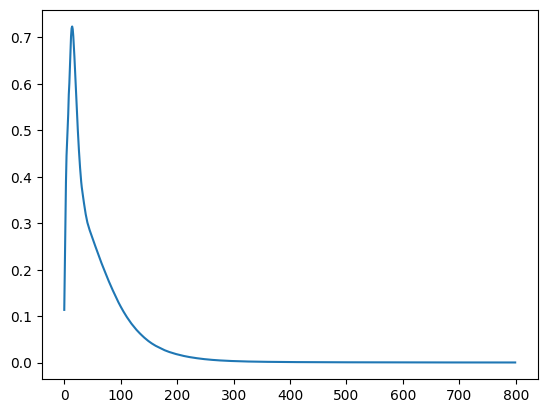

In [ ]:
# Vamos a hacer un plot del loss, a ver qué ha pasado

plt.plot(loss_history)

In [ ]:
# Vamos a evaluar el funcionamiento del modelo

model.eval() # se fijan parametros del modelo para evaluar

# predecimos los valores del rango X_range segun el MLP

# Se pasan a un tensor normalizado
X_range_norm = (X - x_mean) / x_std
X_range_norm = torch.tensor(X_range_norm[:, np.newaxis], dtype=torch.float32)

# Se meten en el modelo
y_mlp_norm = model(X_range_norm)

# Ahora se desnormalizan para que estén en la misma escala
y_mlp_norm = y_mlp_norm.detach().numpy().astype(np.float64) # dejan de ser un tensor
y_mlp = y_mlp_norm * y_std + y_mean # desnormalizan


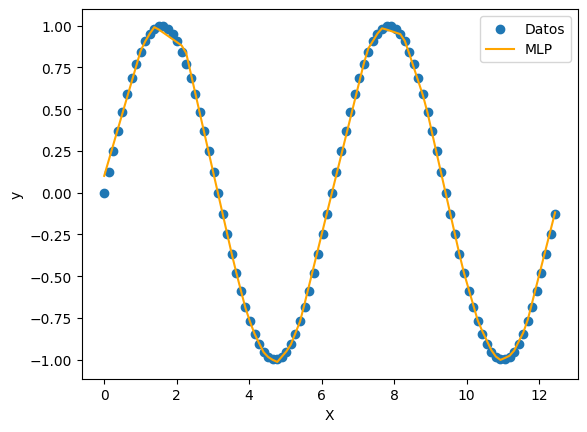

In [ ]:


plt.scatter(X, y, label="Datos")




plt.plot(X, y_mlp, label="MLP", color='orange')

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Ejercicio 3.

Regresión con datos de felicidad

Se analizan unos datos obtenido de Kaggle.com sobre la encuesta de felicidad de 2021: [enlace](https://https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2021)

Una vez limpiados y preparados la base de datos consta de 9 variables predictoras y una variable criterio:

**Criterio**: Life.Ladder.

**Predictoras**: year, Log.GDP.per.capita, Social.support, Healthy.life.expectancy.at.birth, Freedom.to.make.life.choices, Generosity, Perceptions.of.corruption, Positive.affect, Negative.affect.


El mejor modelo calculado con estadística convencional (modelo lineal) da un **MSE de 0.235**

**Supera el MSE de la regresión múltiple**


In [ ]:
%reset -f

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

In [ ]:
# Funciones para importar y preparar los datos

import pandas as pd
url = 'https://raw.githubusercontent.com/mcstllns/UNIR2024/main/data-happiness.csv'
data  = pd.read_csv(url)
print(data.keys())
data.head()

# El fichero tiene datos perdidos y hay que eliminar las filas
data = data.dropna()

# Creamos conjuntos X e y
X = data.drop('Life.Ladder', axis=1)
y = data['Life.Ladder']

print(X.head())
print(y.head())

Index(['year', 'Life.Ladder', 'Log.GDP.per.capita', 'Social.support',
       'Healthy.life.expectancy.at.birth', 'Freedom.to.make.life.choices',
       'Generosity', 'Perceptions.of.corruption', 'Positive.affect',
       'Negative.affect'],
      dtype='object')
   year  Log.GDP.per.capita  Social.support  Healthy.life.expectancy.at.birth  \
0  2008               7.370           0.451                             50.80   
1  2009               7.540           0.552                             51.20   
2  2010               7.647           0.539                             51.60   
3  2011               7.620           0.521                             51.92   
4  2012               7.705           0.521                             52.24   

   Freedom.to.make.life.choices  Generosity  Perceptions.of.corruption  \
0                         0.718       0.168                      0.882   
1                         0.679       0.190                      0.850   
2                         0.

In [ ]:
# preparamos los datos

from torch.utils.data import TensorDataset, DataLoader

# Normalizamos X e y
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_norm = (X - x_mean) / x_std
y_norm = (y - y_mean) / y_std

# Pasamos las variables a tensores
# Ojo, como son dataframes de pandas la sintaxis es un poco diferente

tensor_X = torch.from_numpy(X_norm.values).float()
tensor_y = torch.from_numpy(y_norm.values).float()

# Creamos el dataset y el dataloader
my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset, batch_size=32, shuffle=True) # create your dataloader

In [ ]:
print(tensor_X.shape)
print(tensor_y.shape)

torch.Size([1708, 9])
torch.Size([1708])


In [ ]:
class MLP(torch.nn.Module):
    def __init__(self, X_nvars):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # Hidden Layer 1
            torch.nn.Linear(X_nvars, 64), # Hacemos el sumatorio
            torch.nn.ReLU(),              # Aplicamos la función de activacion

            # Hidden Layer 2
            torch.nn.Linear(64, 32), # Hacemos el sumatorio
            torch.nn.ReLU(),              # Aplicamos la función de activacion


            # output layer
            torch.nn.Linear(32, 1),
        )

    def forward(self, x):
        output = self.layers(x)
        return output

In [ ]:
# Fijamos la semilla a un valor para que los resultados sean identicos
torch.manual_seed(1)

# Ahora fijamos algunos hiper-parámetros

# Creamos el modelo MLP
model = MLP(X_nvars=9)

# Definimos la función loss
loss_fn = torch.nn.MSELoss()

# Elegimos el optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import torch.nn.functional as F

# Fijamos el número de épocas o iteraciones
num_epochs = 500

# Una variables donde vamos a ir guardando los valores del loss para ploterarlos
loss_history = []

for epoch in range(num_epochs):
    model = model.train() # se fijan algunas cosas para hacer entrenamiento

    # En esta parte se define el batch
    # No te preocupes que aún no sabemos qué es
    # MUY IMPORTANTE, nunca uses el mismo nombre que tus datos o los sobreescribe
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        output = model(features)            # Hacemos el forward
        loss = loss_fn(output, targets.view(-1, 1))    # Calculamos el loss

        optimizer.zero_grad()        # Ponemos a cero el gradiente
        loss.backward()              # Calculamos los gradientes (la derivada del loss)
        optimizer.step()             # Cambiamos los pesos de la red

        # Cada cierto tiempo vamos a imprimir un poco de información
        # para saber qué está pasando
        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                # f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss.item():.2f}"
            )
        # añadimos el loss a loss_history
    loss_history.append(loss.item())

Epoch: 001/500 | Batch 000/054 | Train Loss: 0.62
Epoch: 002/500 | Batch 000/054 | Train Loss: 0.24
Epoch: 003/500 | Batch 000/054 | Train Loss: 0.16
Epoch: 004/500 | Batch 000/054 | Train Loss: 0.19
Epoch: 005/500 | Batch 000/054 | Train Loss: 0.16
Epoch: 006/500 | Batch 000/054 | Train Loss: 0.25
Epoch: 007/500 | Batch 000/054 | Train Loss: 0.14
Epoch: 008/500 | Batch 000/054 | Train Loss: 0.19
Epoch: 009/500 | Batch 000/054 | Train Loss: 0.10
Epoch: 010/500 | Batch 000/054 | Train Loss: 0.19
Epoch: 011/500 | Batch 000/054 | Train Loss: 0.25
Epoch: 012/500 | Batch 000/054 | Train Loss: 0.18
Epoch: 013/500 | Batch 000/054 | Train Loss: 0.12
Epoch: 014/500 | Batch 000/054 | Train Loss: 0.19
Epoch: 015/500 | Batch 000/054 | Train Loss: 0.20
Epoch: 016/500 | Batch 000/054 | Train Loss: 0.18
Epoch: 017/500 | Batch 000/054 | Train Loss: 0.11
Epoch: 018/500 | Batch 000/054 | Train Loss: 0.12
Epoch: 019/500 | Batch 000/054 | Train Loss: 0.16
Epoch: 020/500 | Batch 000/054 | Train Loss: 0.16


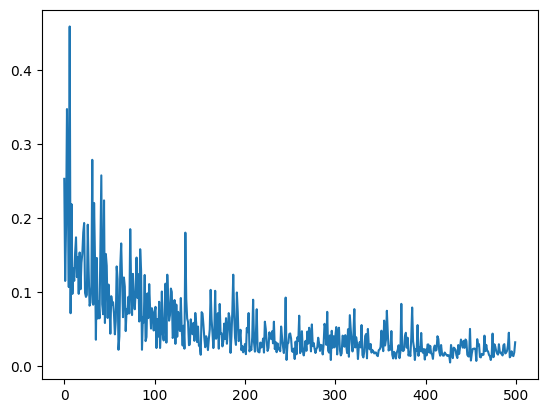

In [ ]:
# Vamos a hacer un plot del loss, a ver qué ha pasado

plt.plot(loss_history)

In [ ]:
# Ponemos el modelo en modo evaluación
model.eval()

# Hacemos las predicciones
with torch.no_grad():
    predicciones_norm = model(tensor_X)

pred_norm_np = predicciones_norm.numpy().flatten()

# Desnormalizamos las predicciones
predicciones_reales = pred_norm_np * y_std + y_mean

# Calculamos el MSE real
from sklearn.metrics import mean_squared_error

mse_final = mean_squared_error(y, predicciones_reales)

print("MSE de la Red Neuronal:", mse_final)
print("MSE de referencia (Regresión Múltiple): 0.235")

MSE de la Red Neuronal: 0.02182072165857059
MSE de referencia (Regresión Múltiple): 0.235
